# Instalar Dependências com uv

Use uv para instalar o SDK do Google Generative AI e outras dependências necessárias no ambiente virtual.

In [16]:
# Instalar dependências
!uv add google-generativeai pillow

Resolved 100 packages in 2ms
Audited 77 packages in 13ms


# Importar Bibliotecas

Importe as bibliotecas necessárias, como google.generativeai, PIL para manipulação de imagens e os para interação com o sistema de arquivos.

In [17]:
import os
import json
from typing import Dict, List
from dataclasses import dataclass, asdict
import google.generativeai as genai
from dotenv import load_dotenv
from PIL import Image
import IPython.display

@dataclass
class ImageInfo:
    """Estrutura para informações de imagem"""
    filename: str
    path: str
    size: tuple
    format: str

@dataclass
class ClassificationResult:
    """Estrutura para resultado de classificação"""
    image_file: str
    category: str
    confidence: str
    analysis: str
    timestamp: str

# Configurar Autenticação da API Gemini

Configure a chave de API do Google e inicialize o cliente do Gemini para autenticação.

In [18]:
#Carregar variáveis de ambiente do arquivo .env
load_dotenv()

# Configurar e validar API Key
api_key = os.getenv("GOOGLE_API_KEY")
config_status = {
    "api_key_loaded": api_key is not None and len(api_key) > 0,
    "api_key_preview": f"{api_key[:10]}...{api_key[-5:]}" if api_key else "NÃO ENCONTRADA",
    "timestamp": str(__import__('datetime').datetime.now())
}

if not api_key:
    print("❌ ERROR: Variável de API não encontrada no arquivo .env (GOOGLE_API_KEY)")
    config_status["status"] = "ERROR"
else:
    genai.configure(api_key=api_key)
    config_status["status"] = "SUCCESS"
    
print("\n📋 STATUS DA CONFIGURAÇÃO:")
print(json.dumps(config_status, indent=2, ensure_ascii=False))


📋 STATUS DA CONFIGURAÇÃO:
{
  "api_key_loaded": true,
  "api_key_preview": "AIzaSyCZHo...Fyt9w",
  "timestamp": "2026-03-13 11:46:24.906272",
  "status": "SUCCESS"
}


# Carregar Imagens da Pasta

Liste e carregue as imagens da pasta 'imagens' usando PIL ou similar para prepará-las para envio à API.

In [19]:
# Carregar imagens da pasta 'imagens'
image_folder = 'imagens'
images = []
loaded_images_info = []

if os.path.exists(image_folder):
    files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    for file in files:
        img_path = os.path.join(image_folder, file)
        img = Image.open(img_path)
        images.append(img)
        
        img_info = ImageInfo(
            filename=file,
            path=img_path,
            size=img.size,
            format=img.format
        )
        loaded_images_info.append(asdict(img_info))
    
    report = {
        "status": "SUCCESS",
        "total_images": len(images),
        "images": loaded_images_info
    }
    print("\n✅ IMAGENS CARREGADAS:")
    print(json.dumps(report, indent=2, ensure_ascii=False))
else:
    print(f"❌ Pasta '{image_folder}' não encontrada. Crie a pasta e adicione imagens.")


✅ IMAGENS CARREGADAS:
{
  "status": "SUCCESS",
  "total_images": 4,
  "images": [
    {
      "filename": "birds.png",
      "path": "imagens\\birds.png",
      "size": [
        275,
        183
      ],
      "format": "JPEG"
    },
    {
      "filename": "cats_dogs.png",
      "path": "imagens\\cats_dogs.png",
      "size": [
        728,
        433
      ],
      "format": "JPEG"
    },
    {
      "filename": "kitchen.png",
      "path": "imagens\\kitchen.png",
      "size": [
        275,
        183
      ],
      "format": "JPEG"
    },
    {
      "filename": "pizza.png",
      "path": "imagens\\pizza.png",
      "size": [
        2500,
        2500
      ],
      "format": "PNG"
    }
  ]
}


# 2. Carregar e exibir imagem
vamos escolher uma imagem para enviar.


🖼️  IMAGEM SELECIONADA:
{
  "status": "LOADED",
  "path": "imagens\\birds.png",
  "filename": "birds.png",
  "dimensions": {
    "width": 275,
    "height": 183,
    "size_mb": 0.0058536529541015625
  },
  "format": "JPEG"
}

Exibindo imagem...


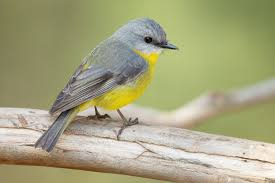

In [20]:
img_path = os.path.join(image_folder, 'birds.png')   # Você pode trocar pelo nome de outra imagem
img = Image.open(img_path)

# Estruturar informações da imagem selecionada
selected_image_info = {
    "status": "LOADED",
    "path": img_path,
    "filename": os.path.basename(img_path),
    "dimensions": {
        "width": img.width,
        "height": img.height,
        "size_mb": os.path.getsize(img_path) / (1024 * 1024)
    },
    "format": img.format
}

print("\n🖼️  IMAGEM SELECIONADA:")
print(json.dumps(selected_image_info, indent=2, ensure_ascii=False))
print("\nExibindo imagem...")
IPython.display.display(img)

# 3. Inicializar o modelo Gerar Imagem com Gemini API

Use o modelo Gemini para gerar uma nova imagem baseada nas imagens carregadas, especificando prompts e parâmetros.

In [21]:
# Gerar Resumo Estruturado da Sessão
summary = {
    "sessão": {
        "inicio": config_status.get("timestamp"),
        "modelo_utilizado": "gemini-2.5-flash"
    },
    "imagens_processadas": {
        "total": len(loaded_images_info),
        "detalhes": loaded_images_info
    },
    "classificação_atual": classification_data if 'classification_data' in locals() else None,
    "status_geral": "COMPLETADO" if 'result' in locals() else "INCOMPLETO"
}

print("\n" + "="*60)
print("📈 RESUMO DA SESSÃO")
print("="*60)
print(json.dumps(summary, indent=2, ensure_ascii=False))


📈 RESUMO DA SESSÃO
{
  "sessão": {
    "inicio": "2026-03-13 11:46:24.906272",
    "modelo_utilizado": "gemini-2.5-flash"
  },
  "imagens_processadas": {
    "total": 4,
    "detalhes": [
      {
        "filename": "birds.png",
        "path": "imagens\\birds.png",
        "size": [
          275,
          183
        ],
        "format": "JPEG"
      },
      {
        "filename": "cats_dogs.png",
        "path": "imagens\\cats_dogs.png",
        "size": [
          728,
          433
        ],
        "format": "JPEG"
      },
      {
        "filename": "kitchen.png",
        "path": "imagens\\kitchen.png",
        "size": [
          275,
          183
        ],
        "format": "JPEG"
      },
      {
        "filename": "pizza.png",
        "path": "imagens\\pizza.png",
        "size": [
          2500,
          2500
        ],
        "format": "PNG"
      }
    ]
  },
  "classificação_atual": null,
  "status_geral": "INCOMPLETO"
}


In [22]:
import datetime

# Inicializar modelo Gemini
model = genai.GenerativeModel('gemini-2.5-flash')

# Enviar imagem para classificação
prompt = """
Classifique a imagem em uma das seguintes categorias:
- Cachorro
- Gato
- Pássaro
- Outro

Responda em JSON com o seguinte formato:
{
    "categoria": "<categoria>",
    "confiança": "<alta/média/baixa>",
    "análise": "<descrição breve do que vê na imagem>"
}
"""

try:
    response = model.generate_content([prompt, img])
    
    # Tentar fazer parse do JSON da resposta
    try:
        # Limpar a resposta para extrair apenas o JSON
        response_text = response.text.strip()
        if response_text.startswith('```json'):
            response_text = response_text[7:]
        if response_text.startswith('```'):
            response_text = response_text[3:]
        if response_text.endswith('```'):
            response_text = response_text[:-3]
        
        classification_data = json.loads(response_text)
    except json.JSONDecodeError:
        classification_data = {
            "categoria": "Não identificada",
            "confiança": "baixa",
            "análise": response.text
        }
    
    # Estruturar resultado final
    result = {
        "timestamp": datetime.datetime.now().isoformat(),
        "imagem": os.path.basename(img_path),
        "modelo": "gemini-2.5-flash",
        "classificação": classification_data,
        "status": "SUCESSO"
    }
    
    print("\n" + "="*60)
    print("📊 RESULTADO DA CLASSIFICAÇÃO:")
    print("="*60)
    print(json.dumps(result, indent=2, ensure_ascii=False))
    
except Exception as e:
    error_result = {
        "status": "ERRO",
        "timestamp": datetime.datetime.now().isoformat(),
        "erro": str(e)
    }
    print("\n❌ ERRO NA CLASSIFICAÇÃO:")
    print(json.dumps(error_result, indent=2, ensure_ascii=False))


📊 RESULTADO DA CLASSIFICAÇÃO:
{
  "timestamp": "2026-03-13T11:46:27.693631",
  "imagem": "birds.png",
  "modelo": "gemini-2.5-flash",
  "classificação": {
    "categoria": "Pássaro",
    "confiança": "alta",
    "análise": "A imagem mostra um pequeno pássaro com plumagem predominantemente cinza na cabeça e dorso, e amarela vibrante no peito e abdômen, empoleirado em um galho de madeira."
  },
  "status": "SUCESSO"
}
